At the end of the notebook there should be models ready to deploy

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 500)

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
import seaborn as sns
rcParams['figure.figsize']=8,5

In [3]:
data_folder = '../data/processed/'

In [4]:
!ls $data_folder

processed_test.csv  processed_train.csv


In [5]:
train_csv = 'processed_train.csv'
test_csv = 'processed_test.csv'
data_folder+train_csv, data_folder+test_csv

('../data/processed/processed_train.csv',
 '../data/processed/processed_test.csv')

# Exploring the datesets

In [6]:
train_df = pd.read_csv(data_folder+train_csv)
test_df = pd.read_csv(data_folder+test_csv)

train_df.shape, test_df.shape

((2000, 88), (500, 78))

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Component1_fraction,2000.0,7.460699e-17,1.000250,-1.107444,-0.923575,-0.249388,0.669958,1.957042
Component2_fraction,2000.0,-1.216804e-16,1.000250,-1.117602,-0.873197,-0.201084,0.715434,1.937458
Component3_fraction,2000.0,1.154632e-16,1.000250,-1.081681,-0.961374,-0.239531,0.662772,1.925996
Component4_fraction,2000.0,-2.398082e-17,1.000250,-2.353856,-0.865375,0.056066,1.119267,1.119267
Component5_fraction,2000.0,-9.903189e-17,1.000250,-1.427567,-0.804121,0.068704,0.816839,2.188421
max_fraction,2000.0,-9.405809e-16,1.000250,-3.332644,-0.619194,0.586783,0.737531,0.737531
min_fraction,2000.0,-3.019807e-17,1.000250,-0.649388,-0.649388,-0.649388,0.455483,4.322533
fraction_range,2000.0,2.939871e-16,1.000250,-4.262037,-0.536924,0.366133,0.817662,0.817662
Fraction1_Property1,2000.0,-8.881784e-18,1.000250,-5.633986,-0.285884,0.010562,0.329351,5.073571
Fraction1_Property2,2000.0,-3.463896e-17,1.000250,-4.985981,-0.303042,0.000357,0.284737,5.108260


In [8]:
num_col = list(train_df.describe().columns) 
num_col

['Component1_fraction',
 'Component2_fraction',
 'Component3_fraction',
 'Component4_fraction',
 'Component5_fraction',
 'max_fraction',
 'min_fraction',
 'fraction_range',
 'Fraction1_Property1',
 'Fraction1_Property2',
 'Fraction1_Property3',
 'Fraction1_Property4',
 'Fraction1_Property5',
 'Fraction1_Property6',
 'Fraction1_Property7',
 'Fraction1_Property8',
 'Fraction1_Property9',
 'Fraction1_Property10',
 'Fraction2_Property1',
 'Fraction2_Property2',
 'Fraction2_Property3',
 'Fraction2_Property4',
 'Fraction2_Property5',
 'Fraction2_Property6',
 'Fraction2_Property7',
 'Fraction2_Property8',
 'Fraction2_Property9',
 'Fraction2_Property10',
 'Fraction3_Property1',
 'Fraction3_Property2',
 'Fraction3_Property3',
 'Fraction3_Property4',
 'Fraction3_Property5',
 'Fraction3_Property6',
 'Fraction3_Property7',
 'Fraction3_Property8',
 'Fraction3_Property9',
 'Fraction3_Property10',
 'Fraction4_Property1',
 'Fraction4_Property2',
 'Fraction4_Property3',
 'Fraction4_Property4',
 'Fracti

# Splitting into training and validation dataset

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
data = train_df[num_col]

In [11]:
target_cols = [ col for col in num_col if "BlendProperty" in col ]
len(target_cols), target_cols

(10,
 ['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'])

In [12]:
X = data.drop(target_cols, axis=1)
y = data[target_cols]

In [13]:
val_size = 0.25 # trian = 75 % and val = 25 %
random_state = 42

In [14]:
X_train, X_val, y_train, y_val = train_test_split( \
            X, y, test_size=val_size, random_state=random_state
        )

In [15]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1500, 78), (500, 78), (1500, 10), (500, 10))

# Training

## Using baseline predictions

In [16]:
y_train.describe()

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.002434,0.004798,-0.031041,-0.007615,-0.032951,-0.017159,-0.029292,-0.004978,-0.000828,0.008489
std,0.998831,1.013191,1.001244,1.008583,0.968130,1.008985,1.003936,1.000045,0.989869,0.982309
min,-2.550897,-3.079759,-3.041624,-2.726882,-1.730111,-2.808210,-2.994571,-3.621080,-3.292727,-2.209607
25%,-0.737914,-0.719897,-0.670976,-0.797149,-0.693927,-0.712228,-0.668323,-0.714771,-0.682735,-0.723361
50%,-0.007668,-0.004265,0.124421,-0.035413,-0.252455,-0.048242,0.112300,-0.001548,-0.007106,-0.002336
75%,0.756756,0.739762,0.696455,0.682796,0.337779,0.693553,0.673603,0.699638,0.690905,0.690500
max,2.856588,2.769156,1.638646,3.769643,3.507660,3.433292,3.293228,3.340657,3.276199,2.708703


### Fitting the baseline model

In [17]:
# y_train_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(y_train) for col in y_train}
# )

In [18]:
# print(y_train_pred.shape)  

In [19]:
# y_train_pred.head()

In [20]:
# y_val_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(y_val) for col in y_train} # median should be used from the traindataset
# )

In [21]:
# print(y_val_pred.shape)

In [22]:
# y_val_pred.describe()

## Other models

In [23]:
from sklearn.multioutput import MultiOutputRegressor

### Random Forest

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rf_basic = MultiOutputRegressor(RandomForestRegressor(
                n_estimators=100, random_state=42, n_jobs=-1
            ))

In [26]:
model_pkl_file = "random_forrest.pkl"  # to be used whlie saving hte model


### Fitting the other models

In [27]:
# model = lr_basic
model = rf_basic


In [28]:
model.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [29]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

##  Evaluation

In [30]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

In [31]:
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

In [32]:
print(f'train_r2: {round(train_r2,5)} ,\nval_r2: {round(val_r2,5)}  ,\ntrain_rmse:  {round(train_rmse,5)}  ,\nval_rmse: {round(val_rmse,5)}   ,\nval_mae: {round(val_mae*100,5)}  ')

train_r2: 0.98767 ,
val_r2: 0.91212  ,
train_rmse:  0.11094  ,
val_rmse: 0.29682   ,
val_mae: 22.1534  


The baseline vlaues are as below;
```
train_r2: -0.00975

val_r2: -0.01272

train_rmse: 1.00199

val_rmse: 1.01016

val_mae: 80.2424
```
These values doesn't make sense. Check what does these mean???

In [33]:
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_train_pct = mape_train * 100 # Converting decimals to percentage

In [34]:
# Printing results
print(f'Mean Absolute Percentage Error TRAIN = {mape_train_pct}%')

Mean Absolute Percentage Error TRAIN = 59.28575352353261%


In [35]:
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
mape_val_pct = mape_val * 100 # Converting decimals to percentage

In [36]:
# Printing results
print(f'Mean Absolute Percentage Error TRAIN = {mape_val_pct}%')

Mean Absolute Percentage Error TRAIN = 489.683815228455%


# Leaderboard Score

In [37]:
cost = mape_val_pct
test_set = "public_testset"
if test_set=='public_testset':
    ref_cost = 2.72
elif test_set=='private_testset':
    ref_cost = 2.58
cost,ref_cost

(489.683815228455, 2.72)

In [38]:
calulated_term = 100 - ((90 * cost)/ref_cost)
calulated_term

-16102.773298000347

In [39]:
leaderboardscore = max(10, calulated_term)

In [40]:
print(f'the score relevant to the competition is {leaderboardscore}')

the score relevant to the competition is 10


# Training selected model on whole train Data set

In [46]:
final_model = model
final_model

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [47]:
%time
final_model.fit(X, y)

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


# Saving trained model

In [48]:
import pickle

In [49]:
model_folder = '../models/'

In [50]:
model_pkl_file = "rf_scaled.pkl"
model_pkl_file

'rf_scaled.pkl'

In [51]:
with open(model_folder+model_pkl_file, 'wb') as file:  
    pickle.dump(model, file)

# Inference

In [52]:
X_train.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'max_fraction',
       'min_fraction', 'fraction_range', 'Fraction1_Property1',
       'Fraction1_Property2', 'Fraction1_Property3', 'Fraction1_Property4',
       'Fraction1_Property5', 'Fraction1_Property6', 'Fraction1_Property7',
       'Fraction1_Property8', 'Fraction1_Property9', 'Fraction1_Property10',
       'Fraction2_Property1', 'Fraction2_Property2', 'Fraction2_Property3',
       'Fraction2_Property4', 'Fraction2_Property5', 'Fraction2_Property6',
       'Fraction2_Property7', 'Fraction2_Property8', 'Fraction2_Property9',
       'Fraction2_Property10', 'Fraction3_Property1', 'Fraction3_Property2',
       'Fraction3_Property3', 'Fraction3_Property4', 'Fraction3_Property5',
       'Fraction3_Property6', 'Fraction3_Property7', 'Fraction3_Property8',
       'Fraction3_Property9', 'Fraction3_Property10', 'Fraction4_Property1',
       'Fraction4_Property2'

In [53]:
len(target_cols),target_cols

(10,
 ['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'])

In [54]:
# test_num_col =  list(set(X_train.columns) - set(target_cols))
# len(test_num_col),test_num_col

In [55]:
X_test = test_df[X_train.columns]
X_test.shape

(500, 78)

## Loading the model

In [56]:
filename = model_folder + model_pkl_file
filename


'../models/rf_scaled.pkl'

In [57]:
loaded_model = pickle.load(open(filename, 'rb'))

In [58]:
loaded_model

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


## using baseline predictions

In [59]:
# y_test_pred = pd.DataFrame(
#     {col: [y_train[col].median()] * len(X_test) for col in y_train}
# )

In [60]:
# print(y_test_pred.shape)

## Using Random forest

In [61]:
y_test_pred = model.predict(X_test)

#  Preparing the submission file



In [62]:
pwd

'/home/pkn/workspace/side_projects/he_shellai_2025/notebooks'

In [63]:
raw_test_df = pd.read_csv('../data/raw/test.csv')
raw_test_df.shape

(500, 56)

In [64]:
test_df['ID'] =raw_test_df['ID']

In [65]:
test_df[target_cols] = y_test_pred
test_df.shape

(500, 89)

In [66]:
test_df.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'max_fraction',
       'min_fraction', 'fraction_range', 'Fraction1_Property1',
       'Fraction1_Property2', 'Fraction1_Property3', 'Fraction1_Property4',
       'Fraction1_Property5', 'Fraction1_Property6', 'Fraction1_Property7',
       'Fraction1_Property8', 'Fraction1_Property9', 'Fraction1_Property10',
       'Fraction2_Property1', 'Fraction2_Property2', 'Fraction2_Property3',
       'Fraction2_Property4', 'Fraction2_Property5', 'Fraction2_Property6',
       'Fraction2_Property7', 'Fraction2_Property8', 'Fraction2_Property9',
       'Fraction2_Property10', 'Fraction3_Property1', 'Fraction3_Property2',
       'Fraction3_Property3', 'Fraction3_Property4', 'Fraction3_Property5',
       'Fraction3_Property6', 'Fraction3_Property7', 'Fraction3_Property8',
       'Fraction3_Property9', 'Fraction3_Property10', 'Fraction4_Property1',
       'Fraction4_Property2'

In [67]:
req_sub_cols = ['ID'] + target_cols
len(req_sub_cols)

11

In [68]:
test_df[req_sub_cols].head()

,ID,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,1,-0.333513,0.277190,0.569441,0.508395,0.340439,0.486197,0.586820,0.502463,-0.303534,0.341858
1,2,-0.450862,-0.343304,-1.211672,-0.035449,-0.741322,-0.081087,-1.188747,-1.241602,-0.007261,0.279418
2,3,1.276395,0.648951,0.717314,0.729226,2.170336,1.466497,0.683912,1.371580,0.131091,1.998388
3,4,-0.224558,0.461098,0.684495,-0.447295,2.048458,-0.193236,0.650140,1.642135,0.810994,-0.703175
4,5,0.240204,-1.095641,1.149434,0.336061,2.404555,0.106070,1.152611,-0.406782,-0.704530,0.794087


<Axes: ylabel='Density'>

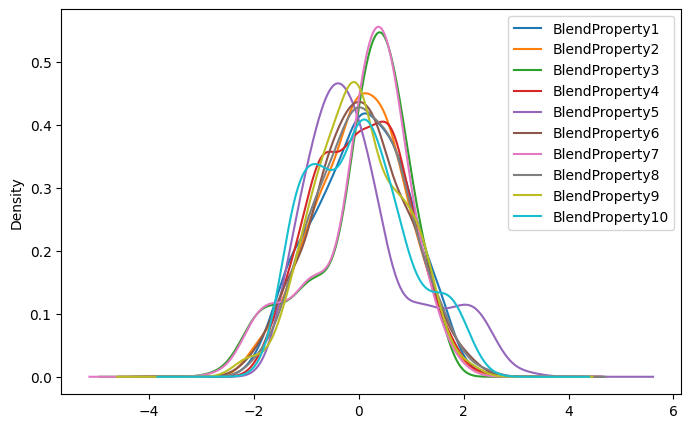

In [69]:
test_df[target_cols].plot.density()

In [70]:
submission_folder = '../data/submission/'

In [71]:
file_name = 'rf_multi_scaled'

In [72]:
test_df[req_sub_cols].to_csv(submission_folder+file_name+'.csv',index=False)